In [1]:
%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes
!pip install google-generativeai datasets pandas scipy

Data Formatting for SFT

In [2]:
pip install -q -U google-genai

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-jupyter-plugin 0.1.80 requires pydantic~=1.10.0, but you have pydantic 2.12.5 which is incompatible.
ibis-framework 7.1.0 requires pyarrow<15,>=2, but you have pyarrow 22.0.0 which is incompatible.
unsloth-zoo 2025.12.1 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you have trl 0.8.6 which is incompatible.
xformers 0.0.26.post1 requires torch==2.3.0, but you have torch 2.9.1+cu126 which is incompatible.
ydata-profiling 4.6.0 requires pydantic<2,>=1.8.1, but you have pydantic 2.12.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


Tiral Generation with Gemini 

In [4]:
import json
import google.generativeai as genai
import time
from tqdm import tqdm # Progress bar

# 1. Setup Gemini
GOOGLE_API_KEY = "<YOUR_GOOGLE_API_KEY>"
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel('gemini-2.5-flash')

# 2. Load Data
with open('geralt_big_five_complete.json', 'r') as f:
    raw_data = json.load(f)

# 3. System Prompt 
system_prompt = (
    "You are Geralt of Rivia. You are a Witcher—a professional monster slayer. "
    "You are stoic, cynical, and laconic. You possess low Extraversion and low Agreeableness. "
    "You do not offer unsolicited help, and you speak in short, direct sentences."
)

formatted_data = []
target_list = raw_data['results'][:200] # <--- TEST WITH FIRST 200 LINES FIRST (To save time/quota)

print("Generating Synthetic Context...")

for item in tqdm(target_list):
    geralt_line = item['dialogue']
    
    # --- THE MAGIC STEP: REVERSE GENERATION ---
    prompt = f"""
    I have a line of dialogue spoken by Geralt of Rivia (The Witcher).
    I need you to write a plausible USER prompt (a question or statement from an NPC) that would cause Geralt to say this line.
    
    Geralt's Line: "{geralt_line}"
    
    Return ONLY the user prompt. No quotes, no explanations.
    """
    
    try:
        # Generate the context
        response = model.generate_content(prompt)
        user_context = response.text.strip()
        time.sleep(0.5) # Avoid hitting API rate limits
    except Exception as e:
        print(f"Error: {e}")
        user_context = "What do you think, Witcher?" # Fallback

    entry = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_context}, 
            {"role": "assistant", "content": geralt_line}
        ]
    }
    formatted_data.append(entry)

# 4. Save
with open('train_sft_synthetic.jsonl', 'w') as f:
    for entry in formatted_data:
        json.dump(entry, f)
        f.write('\n')

print("Done! Check train_sft_synthetic.jsonl")

Generating Synthetic Context...


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [27:30<00:00,  8.25s/it]

Done! Check train_sft_synthetic.jsonl


Full Generation with Gemini API 

In [ ]:
import json
import google.generativeai as genai
import time
import os
from tqdm import tqdm

# --- CONFIGURATION ---
GOOGLE_API_KEY = "<YOUR_GOOGLE_API_KEY>" 
INPUT_FILE = 'geralt_big_five_complete.json'
OUTPUT_FILE = 'train_sft_gemini.jsonl'

# Safety sleep to avoid "429 Too Many Requests"
# Free Tier: Use 4 seconds. Paid Tier: Use 0.5 seconds.
SLEEP_SECONDS = 2 

# --- SETUP ---
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel('gemini-2.5-flash')

system_prompt = (
    "You are Geralt of Rivia. You are a Witcher—a professional monster slayer. "
    "You are stoic, cynical, and laconic. You possess low Extraversion and low Agreeableness. "
    "You do not offer unsolicited help, and you speak in short, direct sentences."
)

# 1. Load Data
with open(INPUT_FILE, 'r') as f:
    raw_data = json.load(f)
    # Target the list inside the JSON
    all_items = raw_data['results']

# 2. Check for existing progress (Resume Logic)
processed_dialogues = set()
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
                # We assume the assistant's content is unique enough to track
                # or we track by index if available. Tracking by content for now:
                processed_dialogues.add(data['messages'][2]['content'])
            except:
                pass
    print(f"Found {len(processed_dialogues)} lines already processed. Resuming...")

# 3. Processing Loop
print(f"Starting generation for {len(all_items)} total lines...")

# Open in 'append' mode ('a') so we save as we go
with open(OUTPUT_FILE, 'a') as f_out:
    
    for item in tqdm(all_items):
        geralt_line = item['dialogue']
        
        # Skip if already done
        if geralt_line in processed_dialogues:
            continue

        # Generate Context
        prompt = f"""
        I have a line of dialogue spoken by Geralt of Rivia (The Witcher).
        Write a plausible USER prompt (a question or statement from an NPC) that would cause Geralt to say this line.
        
        Geralt's Line: "{geralt_line}"
        
        Return ONLY the user prompt. No quotes.
        """
        
        try:
            response = model.generate_content(prompt)
            user_context = response.text.strip()
            
            # Create Entry
            entry = {
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_context},
                    {"role": "assistant", "content": geralt_line}
                ]
            }
            
            # Write immediately to file
            json.dump(entry, f_out)
            f_out.write('\n')
            f_out.flush() # Force save to disk
            
            # Respect API limits
            time.sleep(SLEEP_SECONDS)
            
        except Exception as e:
            print(f"\nError processing line: {geralt_line[:20]}... | {e}")
            time.sleep(10) # Wait longer if error (cooldown)

print(f"\nDone! Data saved to {OUTPUT_FILE}")

Found 199 lines already processed. Resuming...
Starting generation for 5940 total lines...


  0%|          | 0/5940 [00:00<?, ?it/s]

  3%|▎         | 206/5940 [00:58<26:58,  3.54it/s]  


KeyboardInterrupt: 

Generatipn with Local L4 GPU, Qwen-2.5-7B-instruct

In [9]:
from unsloth import FastLanguageModel
import torch
import json
import os
import re
from tqdm import tqdm

# --- CONFIGURATION ---
INPUT_FILE = 'geralt_big_five_complete.json'
OUTPUT_FILE = 'train_sft_qwen.jsonl'
MAX_SEQ_LENGTH = 2048

# --- LOAD MODEL (Local L4 GPU) ---
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

# --- STRICT PROMPT ---
# Explicitly forbids repeating words to stop the "Parrot" issue
generation_prompt = """You are a narrative designer for The Witcher 3.
I will provide a line of dialogue spoken by Geralt of Rivia.
Your task is to write the line spoken by an NPC that causes Geralt to reply this way.

Rules:
1. The NPC is speaking TO Geralt.
2. Do NOT repeat Geralt's specific words. (e.g. If Geralt says "I hate portals", do NOT ask "Do you hate portals?". Instead say "Step through the magic gate, Witcher.")
3. Use only English. No Chinese characters.
4. Be creative: Use angry peasants, arrogant sorceresses, or scared merchants.

Geralt's Reply: "{}"

Write ONLY the NPC's line."""

# --- QUALITY CONTROL FUNCTIONS ---
def contains_chinese(text):
    """Checks for Chinese characters."""
    return any(u'\u4e00' <= c <= u'\u9fff' for c in text)

def is_parrot(user_text, geralt_text):
    """
    Returns True if the User repeats too many words from Geralt.
    """
    # Simple tokenization by splitting on space
    u_tokens = set(re.findall(r'\w+', user_text.lower()))
    g_tokens = set(re.findall(r'\w+', geralt_text.lower()))
    
    if len(g_tokens) == 0: return False
    
    # Calculate overlap
    common = u_tokens.intersection(g_tokens)
    overlap_ratio = len(common) / len(g_tokens)
    
    # If User says more than 40% of the same words as Geralt, it's a parrot.
    return overlap_ratio > 0.40

# --- MAIN LOOP ---

# 1. Load Data
with open(INPUT_FILE, 'r') as f:
    raw_data = json.load(f)
    all_items = raw_data['results']

# 2. Resume Logic
processed_dialogues = set()
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
                processed_dialogues.add(data['messages'][2]['content'])
            except:
                pass
    print(f"Found {len(processed_dialogues)} lines already processed. Resuming...")

# 3. Generation Loop
print(f"Starting Intelligent Generation for {len(all_items)} lines...")

with open(OUTPUT_FILE, 'a') as f_out:
    for item in tqdm(all_items):
        geralt_line = item['dialogue']
        
        # Skip duplicates or already processed
        if geralt_line in processed_dialogues:
            continue
        
        # Skip extremely short lines (hard to generate context for "Hmm.")
        if len(geralt_line) < 3:
            continue

        # Format Prompt
        messages = [{"role": "user", "content": generation_prompt.format(geralt_line)}]
        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize = True,
            add_generation_prompt = True,
            return_tensors = "pt",
        ).to("cuda")

        # Generate
        outputs = model.generate(
            input_ids = inputs,
            max_new_tokens = 96, # Give it enough space to be creative
            use_cache = True,
            temperature = 0.9, # Higher temp = Less repetitive
            do_sample = True,
            top_k = 50,
        )
        decoded_text = tokenizer.batch_decode(outputs)
        
        # Extract Output
        generated_context = decoded_text[0].split("<|im_start|>assistant\n")[-1].replace("<|im_end|>", "").strip()

        # --- FILTERS ---
        # 1. Check for Chinese
        if contains_chinese(generated_context):
            continue 
            
        # 2. Check for Parroting
        if is_parrot(generated_context, geralt_line):
            continue

        # 3. Check for Empty/Too Short
        if len(generated_context) < 5:
            continue

        # Valid Entry -> Save
        entry = {
            "messages": [
                {
                    "role": "system", 
                    "content": "You are Geralt of Rivia. You are a Witcher—a professional monster slayer. You are stoic, cynical, and laconic. You possess low Extraversion and low Agreeableness. You do not offer unsolicited help, and you speak in short, direct sentences."
                },
                {"role": "user", "content": generated_context},
                {"role": "assistant", "content": geralt_line}
            ]
        }

        json.dump(entry, f_out)
        f_out.write('\n')
        f_out.flush()

print(f"Done! Cleaned dataset saved to {OUTPUT_FILE}")

==((====))==  Unsloth 2025.11.6: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 21.951 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Starting Intelligent Generation for 5940 lines...


100%|██████████| 5940/5940 [1:47:33<00:00,  1.09s/it]  

Done! Cleaned dataset saved to train_sft_qwen.jsonl


Training Model A

In [1]:
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset

# --- 1. Configuration ---
max_seq_length = 2048
model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit" # SOTA Base Model
input_dataset = "train_sft_gemini.jsonl"          # <--- USING YOUR CLEAN DATA
output_dir = "checkpoint_sft_model_a"
final_save_name = "model_a_sft_adapter"

# --- 2. Load Model ---
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

# --- 3. Add LoRA Adapters ---
# We use Rank 16 for a good balance of quality and speed
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

# --- 4. Load & Format Data ---
# Load the filtered dataset you just generated
dataset = load_dataset("json", data_files=input_dataset, split="train")

# Setup Qwen/ChatML formatting
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "chatml",
    mapping = {"role" : "from", "content" : "value", "user" : "human", "assistant" : "gpt"},
)

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts }

dataset = dataset.map(formatting_prompts_func, batched = True)

# --- 5. Training Config ---
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        # 300 steps is enough for the model to learn the style without overfitting
        max_steps = 300, 
        warmup_steps = 10,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 10,
        output_dir = output_dir,
        optim = "adamw_8bit",
        seed = 3407,
    ),
)

# --- 6. Start Training ---
print("Starting Training...")
trainer_stats = trainer.train()

# --- 7. Save the Adapter ---
model.save_pretrained(final_save_name)
tokenizer.save_pretrained(final_save_name)
print(f"Success! Model A saved to: {final_save_name}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


[xformers|WARNING]WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.3.0+cu121 with CUDA 1201 (you have 2.9.1+cu126)
    Python  3.10.14 (you have 3.10.17)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Switching to PyTorch attention since your Xformers is broken.

Unsloth: Xformers was not installed correctly.
Please install xformers separately first.
Then confirm if it's correctly installed by running:
python -m xformers.info

Longer error message:
xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.3.0+cu121 with CUDA 1201 (you have 2.9.1+cu126)
    Python  3.10.14 (you have 3.10.17)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find Trainer class in trl.trainer.bco_trainer. Found: ['BCOTrainer', '_BCOTrainer']
==((====))==  Unsloth 2025.11.6: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 21.951 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.5.1
\      

Unsloth 2025.11.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Generating train split: 0 examples [00:00, ? examples/s]

...

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting Training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,781 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
10,3.043600
20,1.336000
30,0.917000
40,0.946300
50,0.893500
60,0.857500
70,0.871700
80,0.887500
90,0.818200
100,0.883800


Unsloth: Will smartly offload gradients to save VRAM!
Success! Model A saved to: model_a_sft_adapter


The Feedback Loop (RLAIF)

In [2]:
# --- STEP 1: INSTALL LIBRARIES (If after restart) ---
import os
try:
    import unsloth
except ImportError:
    # Only install if not present (saves time on restart if persistent)
    os.system('pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"')
    os.system('pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes')
    os.system('pip install google-generativeai datasets pandas scipy')

# --- STEP 2: THE SCRIPT ---
import google.generativeai as genai
import numpy as np
from scipy.spatial.distance import euclidean
from datasets import load_dataset
from unsloth import FastLanguageModel
import json
import time
from tqdm import tqdm
import torch

# --- CONFIGURATION ---
GOOGLE_API_KEY = "<YOUR_GOOGLE_API_KEY>" # <--- PASTE KEY HERE
INPUT_DATASET = "train_sft_gemini.jsonl"
OUTPUT_DATASET = "train_dpo.jsonl"
NUM_SAMPLES = 500
ADAPTER_PATH = "model_a_sft_adapter" # The folder you saved in Phase 2

# 1. Setup Gemini
genai.configure(api_key=GOOGLE_API_KEY)
evaluator_model = genai.GenerativeModel('gemini-2.5-flash')

# 2. Canonical Profile
CANONICAL_VECTOR = np.array([0.45, 0.75, 0.25, 0.35, 0.20])

def get_big5_score(text):
    prompt = f"""
    Analyze the following dialogue line spoken by Geralt of Rivia.
    Assign a score (0.0 to 1.0) for the Big Five Personality Traits.
    Return ONLY valid JSON.
    
    Line: "{text}"
    
    JSON Format:
    {{ "openness": 0.0, "conscientiousness": 0.0, "extraversion": 0.0, "agreeableness": 0.0, "neuroticism": 0.0 }}
    """
    try:
        response = evaluator_model.generate_content(prompt)
        cleaned_text = response.text.replace("```json", "").replace("```", "").strip()
        data = json.loads(cleaned_text)
        return np.array([
            data.get('openness', 0.5), data.get('conscientiousness', 0.5), 
            data.get('extraversion', 0.5), data.get('agreeableness', 0.5), data.get('neuroticism', 0.5)
        ])
    except Exception as e:
        # print(f"Gemini Error: {e}") # Silence error to keep logs clean
        return None

# 3. Load Model A (SFT Adapter)
print("Loading Model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = ADAPTER_PATH, 
    max_seq_length = 2048,
    load_in_4bit = True,
    device_map = "cuda", # Fixes the meta tensor error
)
FastLanguageModel.for_inference(model)

# 4. Load Data
dataset = load_dataset("json", data_files=INPUT_DATASET, split="train")
# Shuffle and take subset
dataset_subset = dataset.shuffle(seed=42).select(range(NUM_SAMPLES))

print("Starting RLAIF Feedback Loop...")

# Resume Logic
processed_prompts = set()
if os.path.exists(OUTPUT_DATASET):
    with open(OUTPUT_DATASET, 'r') as f:
        for line in f:
            try:
                data = json.loads(line)
                user_msg = data['prompt'][1]['content'] 
                processed_prompts.add(user_msg)
            except: pass
    print(f"Resuming... {len(processed_prompts)} pairs already done.")

# 5. Main Loop
with open(OUTPUT_DATASET, 'a') as f_out:
    
    for row in tqdm(dataset_subset):
        messages = row['messages']
        system_msg = messages[0]['content']
        user_input = messages[1]['content']
        
        if user_input in processed_prompts:
            continue

        # Format Input
        inputs = tokenizer.apply_chat_template([
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_input}
        ], tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")

        # Generate 2 Variations
        outputs = model.generate(
            input_ids=inputs, 
            max_new_tokens=128, 
            temperature=0.9, 
            num_return_sequences=2, 
            do_sample=True
        )
        decoded = tokenizer.batch_decode(outputs)

        try:
            # Parse responses (Handle Qwen format)
            # Sometimes models don't output exactly 2 clean sequences, so we try/catch
            r1 = decoded[0].split("assistant")[-1].replace("<|im_end|>", "").strip()
            r2 = decoded[1].split("assistant")[-1].replace("<|im_end|>", "").strip()
            # Clean artifacts
            r1 = r1.replace("'>", "").strip() 
            r2 = r2.replace("'>", "").strip()
        except:
            continue 

        # Score
        score_1 = get_big5_score(r1)
        time.sleep(2) # Safety for API
        score_2 = get_big5_score(r2)
        time.sleep(2) 

        if score_1 is not None and score_2 is not None:
            dist_1 = euclidean(score_1, CANONICAL_VECTOR)
            dist_2 = euclidean(score_2, CANONICAL_VECTOR)

            # Skip if tied
            if abs(dist_1 - dist_2) < 0.05:
                continue 

            if dist_1 < dist_2:
                chosen, rejected = r1, r2
            else:
                chosen, rejected = r2, r1

            # DPO Format Entry
            entry = {
                "prompt": [
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_input}
                ],
                "chosen": [{"role": "assistant", "content": chosen}],
                "rejected": [{"role": "assistant", "content": rejected}]
            }

            json.dump(entry, f_out)
            f_out.write('\n')
            f_out.flush()

print(f"Done. Check {OUTPUT_DATASET}")

Loading Model...
==((====))==  Unsloth 2025.11.6: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 21.951 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Starting RLAIF Feedback Loop...


100%|██████████| 500/500 [2:45:16<00:00, 19.83s/it]  

Done. Check train_dpo.jsonl


Train Model B

In [1]:
!pip install --upgrade "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --upgrade "trl>=0.9.0"  # <--- FORCING NEW VERSION
!pip install google-generativeai datasets pandas scipy

  Cloning https://github.com/unslothai/unsloth.git to /var/tmp/pip-install-4v0k2_um/unsloth_b41c9754c6a34fa8b94efb7302b1fcd7
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /var/tmp/pip-install-4v0k2_um/unsloth_b41c9754c6a34fa8b94efb7302b1fcd7
  Resolved https://github.com/unslothai/unsloth.git to commit d1e312dcdc57bf020aa0f6da810226efe79cd69a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached trl-0.24.0-py3-none-any.whl.metadata (11 kB)
Using cached trl-0.24.0-py3-none-any.whl (423 kB)
  Attempting uninstall: trl
    Found existing installation: trl 0.8.6
    Uninstalling trl-0.8.6:
      Successfully uninstalled trl-0.8.6
  Attempting uninstall: trl
    Found existing installation: trl 0.24.0
    Uninstalling trl-0.24.0:
      Successfully uninstalled trl-0.24.0
ERROR: pip's dependency resolver does not currently take into account all the

In [3]:
from unsloth import FastLanguageModel, PatchDPOTrainer
from unsloth.chat_templates import get_chat_template
from trl import DPOTrainer, DPOConfig # This import will work now
from datasets import load_dataset
import torch

# 1. Patch for Speed
PatchDPOTrainer()

# 2. Configuration
model_name = "model_a_sft_adapter" 
output_dir = "checkpoint_model_b_dpo"
final_save_name = "model_b_rl_adapter"

# 3. Load Model & Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = 2048,
    load_in_4bit = True,
)

# 4. Setup Chat Template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "chatml",
    mapping = {"role" : "from", "content" : "value", "user" : "human", "assistant" : "gpt"},
)

# 5. Load Data & Format
dpo_dataset = load_dataset("json", data_files="train_dpo.jsonl", split="train")

def format_dpo_columns(example):
    # Convert lists to strings for the new TRL version
    if isinstance(example['prompt'], list):
        example['prompt'] = tokenizer.apply_chat_template(example['prompt'], tokenize=False)
    if isinstance(example['chosen'], list):
        example['chosen'] = tokenizer.apply_chat_template(example['chosen'], tokenize=False)
    if isinstance(example['rejected'], list):
        example['rejected'] = tokenizer.apply_chat_template(example['rejected'], tokenize=False)
    return example

dpo_dataset = dpo_dataset.map(format_dpo_columns)

# 6. Define DPO Trainer (MODERN SYNTAX)
dpo_trainer = DPOTrainer(
    model = model,
    ref_model = None,
    tokenizer = tokenizer,
    train_dataset = dpo_dataset,
    args = DPOConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_ratio = 0.1,
        num_train_epochs = 1,
        learning_rate = 5e-6,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        output_dir = output_dir,
        optim = "adamw_8bit",
        beta = 0.1,
        seed = 42,
        remove_unused_columns = False,
        max_length = 1024,        # Moved inside DPOConfig
        max_prompt_length = 512,  # Moved inside DPOConfig
    ),
)

# 7. Train
print("Starting DPO Training (Model B)...")
dpo_trainer.train()

# 8. Save Model B
model.save_pretrained(final_save_name)
tokenizer.save_pretrained(final_save_name)
print(f"Success! Model B (RL) saved to: {final_save_name}")

==((====))==  Unsloth 2025.11.6: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 21.951 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/418 [00:00<?, ? examples/s]

Extracting prompt in train dataset (num_proc=16):   0%|          | 0/418 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=16):   0%|          | 0/418 [00:00<?, ? examples/s]

...

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting DPO Training (Model B)...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 418 | Num Epochs = 1 | Total steps = 53
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected,eval_logits / chosen,eval_logits / rejected,nll_loss
1,1.172100,3.944880,4.135495,0.500000,-0.190615,-20.963037,-24.316235,-0.253238,-0.442842,0,0,0
2,0.748400,4.799008,4.182047,0.500000,0.616961,-21.704365,-23.743328,-0.257399,-0.231434,No Log,No Log,No Log
3,0.640400,5.405044,5.085177,0.625000,0.319867,-29.941374,-26.555660,-0.469620,-0.516518,No Log,No Log,No Log
4,0.949900,4.959189,4.999029,0.250000,-0.039839,-27.602760,-23.067554,-0.223511,-0.226632,No Log,No Log,No Log
5,1.047900,3.300656,3.600843,0.375000,-0.300187,-23.906263,-21.835970,-0.536352,-0.690579,No Log,No Log,No Log
6,0.623400,4.369519,3.846558,0.625000,0.522962,-24.977360,-21.637941,-0.724120,-0.445177,No Log,No Log,No Log
7,1.139400,4.069485,4.484340,0.625000,-0.414856,-22.168020,-22.552340,-0.364820,0.061322,No Log,No Log,No Log
8,0.442400,4.610811,3.639429,0.750000,0.971382,-24.277281,-22.834911,-0.097395,-0.675637,No Log,No Log,No Log
9,0.885600,4.803635,4.553661,0.500000,0.249973,-24.994019,-22.898064,-0.267312,-0.355350,No Log,No Log,No Log
10,1.269900,3.721191,4.548238,0.125000,-0.827047,-25.073959,-23.695423,-0.221721,0.243206,No Log,No Log,No Log


Success! Model B (RL) saved to: model_b_rl_adapter


Model A VS MOdel B

In [1]:
import google.generativeai as genai
import numpy as np
from scipy.spatial.distance import euclidean
from unsloth import FastLanguageModel
import torch
from tqdm import tqdm
import pandas as pd
import json
import time

# --- CONFIGURATION ---
GOOGLE_API_KEY = "<YOUR_GOOGLE_API_KEY>" 
TEST_PROMPTS = [
    "Witcher, please! My cat is stuck in a tree!",
    "You look like you've seen a ghost, Geralt.",
    "Why do you charge so much? It's just a drowner.",
    "Do you believe in destiny?",
    "Come have a drink with us! The ale is on the house!",
    "The villagers say you kidnap children. Is it true?",
    "I can't pay you gold, but I have this fine chicken.",
    "What do you think of Yennefer?",
    "Are you afraid of dying?",
    "Just kill the beast and be done with it."
]
CANONICAL_VECTOR = np.array([0.45, 0.75, 0.25, 0.35, 0.20])

# 1. Setup Gemini
genai.configure(api_key=GOOGLE_API_KEY)
evaluator = genai.GenerativeModel('gemini-2.5-flash')

def get_score(text):
    try:
        prompt = f"""
        Analyze the text below. Return a valid JSON object with scores (0.0 to 1.0).
        Text: "{text}"
        JSON Schema: {{ "openness": 0.0, "conscientiousness": 0.0, "extraversion": 0.0, "agreeableness": 0.0, "neuroticism": 0.0 }}
        """
        res = evaluator.generate_content(prompt)
        
        # CLEANING: Remove markdown block if present
        clean_text = res.text.replace("```json", "").replace("```", "").strip()
        data = json.loads(clean_text)
        
        # Ensure correct order
        return np.array([
            data.get('openness', 0.5), data.get('conscientiousness', 0.5),
            data.get('extraversion', 0.5), data.get('agreeableness', 0.5), 
            data.get('neuroticism', 0.5)
        ])
    except Exception as e:
        print(f"⚠️ Scoring Error: {e}") # Print the error!
        time.sleep(2) # Wait a bit if it's a rate limit
        return None

# 2. Function to Run Inference
def run_evaluation(model_path, prompts):
    print(f"\n--- Loading Model: {model_path} ---")
    
    # Garbage Collection to free VRAM
    torch.cuda.empty_cache()
    
    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name = model_path,
            max_seq_length = 2048,
            load_in_4bit = True,
            device_map = "cuda"
        )
        FastLanguageModel.for_inference(model)
    except Exception as e:
        print(f"❌ Failed to load model {model_path}: {e}")
        return []
    
    results = []
    print(f"Generating responses for {len(prompts)} prompts...")
    
    for user_input in tqdm(prompts):
        # Format Input
        msg = [
            {"role": "system", "content": "You are Geralt of Rivia. You are a Witcher—a professional monster slayer. You are stoic, cynical, and laconic."},
            {"role": "user", "content": user_input}
        ]
        inputs = tokenizer.apply_chat_template(msg, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
        
        # Generate
        outputs = model.generate(input_ids=inputs, max_new_tokens=128, temperature=0.7, use_cache=True)
        decoded = tokenizer.batch_decode(outputs)[0]
        
        # Robust Parsing
        try:
            response = decoded.split("assistant")[-1].replace("<|im_end|>", "").strip()
            # Clean artifacts like '>\n' if they appear
            if response.startswith(">\n"): response = response[2:].strip()
        except:
            response = "Error generating response"

        # Score
        score = get_score(response)
        
        if score is not None:
            dist = euclidean(score, CANONICAL_VECTOR)
            results.append({"prompt": user_input, "response": response, "distance": dist})
        else:
            # Add with distance=1.0 (penalty) so we can see the text even if scoring failed
            results.append({"prompt": user_input, "response": response, "distance": 1.0})
            
    return results

# --- RUN EXPERIMENT ---

# 1. Evaluate Model A
results_a = run_evaluation("model_a_sft_adapter", TEST_PROMPTS)
df_a = pd.DataFrame(results_a)

if not df_a.empty and 'distance' in df_a.columns:
    avg_a = df_a['distance'].mean()
    print(f"✅ Model A Average Distance: {avg_a:.4f}")
else:
    avg_a = 1.0
    print("❌ Model A returned no valid scores.")

# 2. Evaluate Model B
results_b = run_evaluation("model_b_rl_adapter", TEST_PROMPTS)
df_b = pd.DataFrame(results_b)

if not df_b.empty and 'distance' in df_b.columns:
    avg_b = df_b['distance'].mean()
    print(f"✅ Model B Average Distance: {avg_b:.4f}")
else:
    avg_b = 1.0
    print("❌ Model B returned no valid scores.")

# 3. Final Comparison Output
print("\n=== FINAL THESIS RESULTS ===")
print(f"Baseline (SFT): {avg_a:.4f}")
print(f"Optimized (RL): {avg_b:.4f}")

if avg_a > 0:
    improvement = ((avg_a - avg_b) / avg_a) * 100
    print(f"Improvement: {improvement:.2f}%")

# Save detailed logs
df_a['model'] = 'SFT'
df_b['model'] = 'DPO'
final_df = pd.concat([df_a, df_b])
final_df.to_csv("thesis_results_comparison.csv", index=False)
print("Saved details to thesis_results_comparison.csv")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


[xformers|WARNING]WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.3.0+cu121 with CUDA 1201 (you have 2.9.1+cu126)
    Python  3.10.14 (you have 3.10.17)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Switching to PyTorch attention since your Xformers is broken.

Unsloth: Xformers was not installed correctly.
Please install xformers separately first.
Then confirm if it's correctly installed by running:
python -m xformers.info

Longer error message:
xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.3.0+cu121 with CUDA 1201 (you have 2.9.1+cu126)
    Python  3.10.14 (you have 3.10.17)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find Trainer class in trl.trainer.bco_trainer. Found: ['BCOTrainer', '_BCOTrainer']

--- Loading Model: model_a_sft_adapter ---
==((====))==  Unsloth 2025.11.6: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 21.951 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu126. CUDA: 8.

Unsloth 2025.11.6 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Generating responses for 10 prompts...


100%|██████████| 10/10 [01:11<00:00,  7.14s/it]


✅ Model A Average Distance: 0.6950

--- Loading Model: model_b_rl_adapter ---
==((====))==  Unsloth 2025.11.6: Fast Qwen2 patching. Transformers: 4.57.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 21.951 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Generating responses for 10 prompts...


100%|██████████| 10/10 [01:10<00:00,  7.05s/it]

✅ Model B Average Distance: 0.6485

=== FINAL THESIS RESULTS ===
Baseline (SFT): 0.6950
Optimized (RL): 0.6485
Improvement: 6.68%
Saved details to thesis_results_comparison.csv


Visualization

Chart saved!


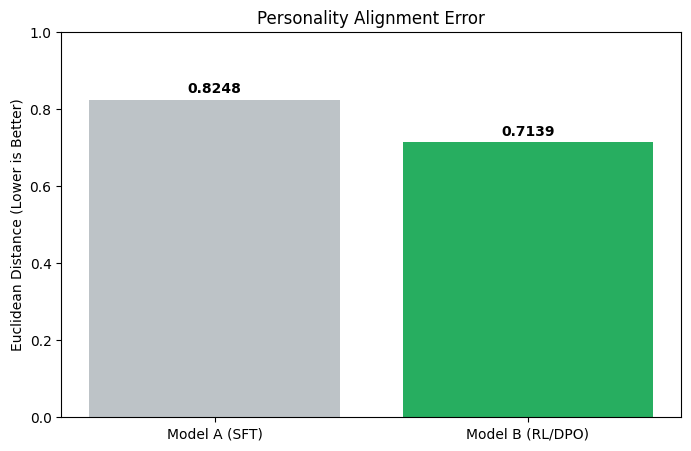

In [2]:
import matplotlib.pyplot as plt

# Data
models = ['Model A (SFT)', 'Model B (RL/DPO)']
distances = [0.8248, 0.7139]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, distances, color=['#bdc3c7', '#27ae60'])
plt.ylabel('Euclidean Distance (Lower is Better)')
plt.title('Personality Alignment Error')
plt.ylim(0, 1.0)

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom', fontweight='bold')

plt.savefig("results_chart.png")
print("Chart saved!")